In [1]:
import tensorflow as tf

In [2]:
# Load the Fashion MNIST dataset
mnist = tf.keras.datasets.mnist

In [3]:
mnist

<module 'keras.datasets.mnist' from '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/datasets/mnist/__init__.py'>

In [24]:
from tensorflow.keras.datasets import mnist
import numpy as np

data = np.load("mnist.npz")
data
training_images = data["x_train"]
training_labels = data["y_train"]
test_images = data["x_test"]
test_labels = data["y_test"]
# (training_images, training_labels), (test_images, test_labels) =   np.load("mnist.npz")
# (x_train, y_train), (x_test, y_test) = mnist.load_data(path="mnist.npz")

# print(x_train.shape, y_train.shape)


IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 190  25   0   0   0   0   0   0   0   0]
 [  0   0   0  13  25  10   0   0   0   0   0   0   0   0   0   0   0 112 252 125   4   0   0   0   0   0   0   0]
 [  0   0   0 132 252 113   0   0   0   0   0   0   0   0   0   0   0  61 252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 240  79   0   0   0   0   0   0   0   0   0   0  84 252 252  36   0   0   0   0   0   0   0]
 [  0   0   0 132 252 252 238  52   0   0   0   0   0   0  

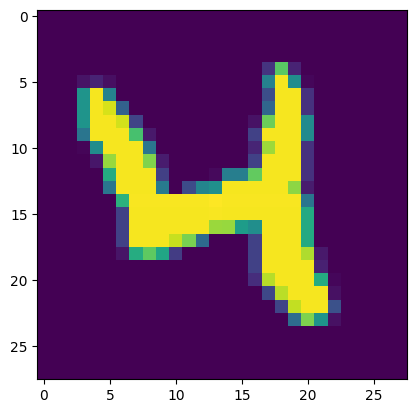

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
# index = 3
index = 20

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
print(f'LABEL: {training_labels[index]}')
plt.imshow(training_images[index])
plt.show()

In [26]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [27]:
# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(), # this is input layer
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu), #this is black box layer
                                     tf.keras.layers.Dense(64, activation=tf.nn.relu), # this is black box layer
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)]) # this is ouput layer

In [28]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 689us/step - accuracy: 0.9283 - loss: 0.2431
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step - accuracy: 0.9690 - loss: 0.1004
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.9780 - loss: 0.0696
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - accuracy: 0.9829 - loss: 0.0535
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step - accuracy: 0.9858 - loss: 0.0436
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - accuracy: 0.9891 - loss: 0.0336
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step - accuracy: 0.9905 - loss: 0.0290
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.9919 - loss: 0.0239
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - accuracy: 0.9925 - loss: 0.0228
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 622us/step - accuracy: 0.9939 - loss: 0.0182
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step - accuracy: 0.9937 - loss: 0.01

In [29]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step - accuracy: 0.9800 - loss: 0.3209


[0.32091379165649414, 0.9800000190734863]

In [30]:
classifications = model.predict(test_images)
print(classifications[3])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step
[1.0000000e+00 0.0000000e+00 7.1415704e-34 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.9663189e-31 3.0318026e-23 6.6010311e-38 2.8153591e-33]


In [31]:
print(test_labels[3])

0


In [36]:
# Upload your own image and predict the Fashion MNIST class
# Run this cell AFTER training the model.

from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Fashion MNIST class names
# class_names = [
#     "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
#     "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
# ]

# Upload an image file: png, jpg, jpeg, etc.
uploaded = Image.open('mnist_sample_img.png')

for file_name in uploaded.keys():
    # 1. Open uploaded image
    img = Image.open(file_name).convert("L")   # convert to grayscale

    # 2. Resize image to 28 x 28 because Fashion MNIST images are 28x28
    img = img.resize((28, 28))
 # 3. Fashion MNIST usually has a dark background and light object.
    # If your uploaded image has a white background, invert it.
    img = ImageOps.invert(img)

    # 4. Convert image into numpy array and normalize values from 0 to 1
    img_array = np.array(img) / 255.0

    # 5. Add batch dimension: model expects shape (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # 6. Predict
    prediction = model.predict(img_input)
    predicted_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    # 7. Show result
    plt.imshow(img_array, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]} ({confidence:.2f}% confidence)")
    plt.show()

    print("Uploaded file:", file_name)
    print("Predicted class number:", predicted_index)
    print("Predicted class name:", class_names[predicted_index])
    print(f"Confidence: {confidence:.2f}%")
    for name, prob in zip(class_names, prediction[0]):
        print(f"{name}: {prob*100:.2f}%")

<PIL.PngImagePlugin.PngImageFile image mode=P size=225x224 at 0x15DB89CD0>


AttributeError: 'PngImageFile' object has no attribute 'keys'

In [18]:
# Load the training and test split of the  MNIST dataset
# (training_images, training_labels), (test_images, test_labels) = mnist.load_data()